IMPORT ALL THE REQURIED LIBRARIES


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Then ML-related libraries:


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

Load Dataset

In [4]:
df=pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

Basic Data Exploration (EDA – Part 1)

In [5]:
df.head(5)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35096 entries, 0 to 35095
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_012          35096 non-null  float64
 1   HighBP                35096 non-null  float64
 2   HighChol              35096 non-null  float64
 3   CholCheck             35096 non-null  float64
 4   BMI                   35096 non-null  float64
 5   Smoker                35096 non-null  float64
 6   Stroke                35096 non-null  float64
 7   HeartDiseaseorAttack  35096 non-null  float64
 8   PhysActivity          35096 non-null  float64
 9   Fruits                35095 non-null  float64
 10  Veggies               35095 non-null  float64
 11  HvyAlcoholConsump     35095 non-null  float64
 12  AnyHealthcare         35095 non-null  float64
 13  NoDocbcCost           35095 non-null  float64
 14  GenHlth               35095 non-null  float64
 15  MentHlth           

In [7]:
df.shape

(35096, 22)

In [8]:
df.isnull().sum()

,0
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,1


In [9]:
df.duplicated().sum()

np.int64(1269)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

Rename target column

In [12]:
df.rename(columns={'Diabetes_012': 'Diabetes'}, inplace=True)

Exploratory Data Analysis (EDA – Part 2 Visualization)

Text(0.5, 1.0, 'Diabetes vs HighBP')

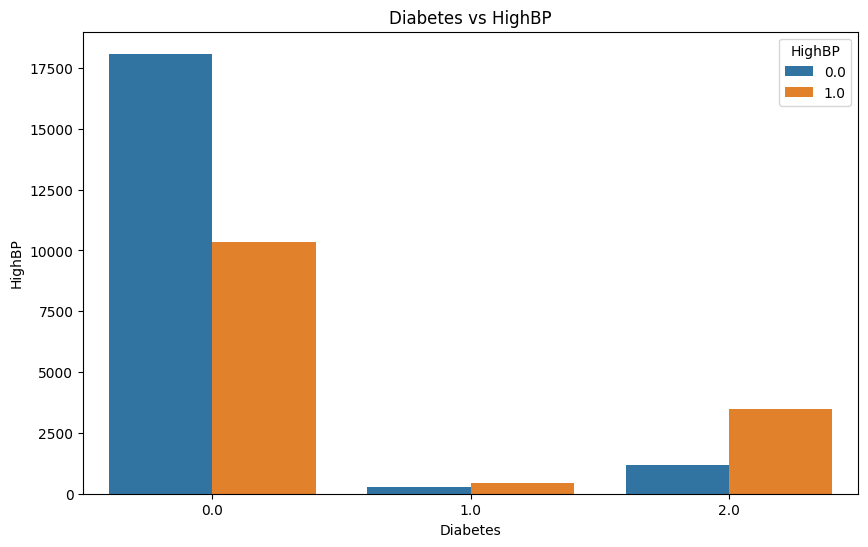

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Diabetes', hue='HighBP', data=df)
plt.xlabel('Diabetes')
plt.ylabel('HighBP')
plt.title('Diabetes vs HighBP')

Text(0.5, 1.0, 'Diabetes vs Age')

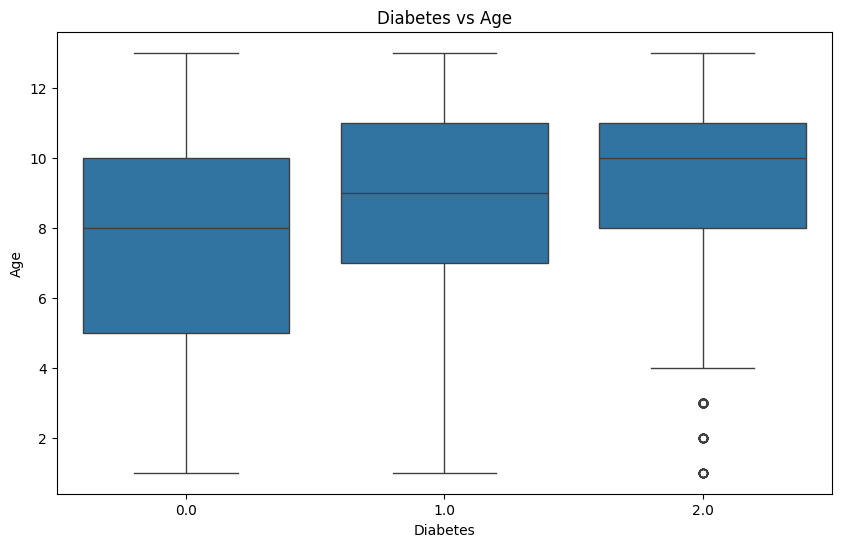

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes', y='Age', data=df)
plt.xlabel('Diabetes')
plt.ylabel('Age')
plt.title('Diabetes vs Age')


Text(0.5, 1.0, 'Diabetes vs BMI')

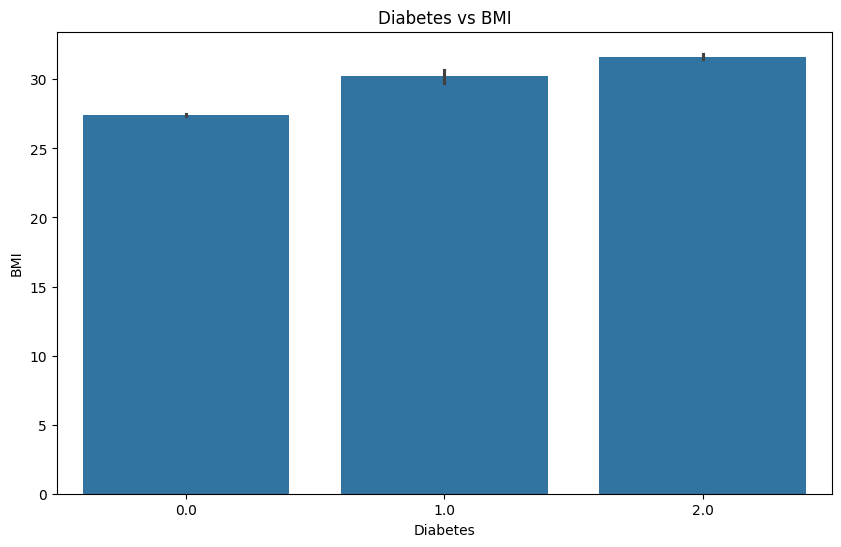

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Diabetes', y='BMI')
plt.xlabel('Diabetes')
plt.ylabel('BMI')
plt.title('Diabetes vs BMI')

<Axes: >

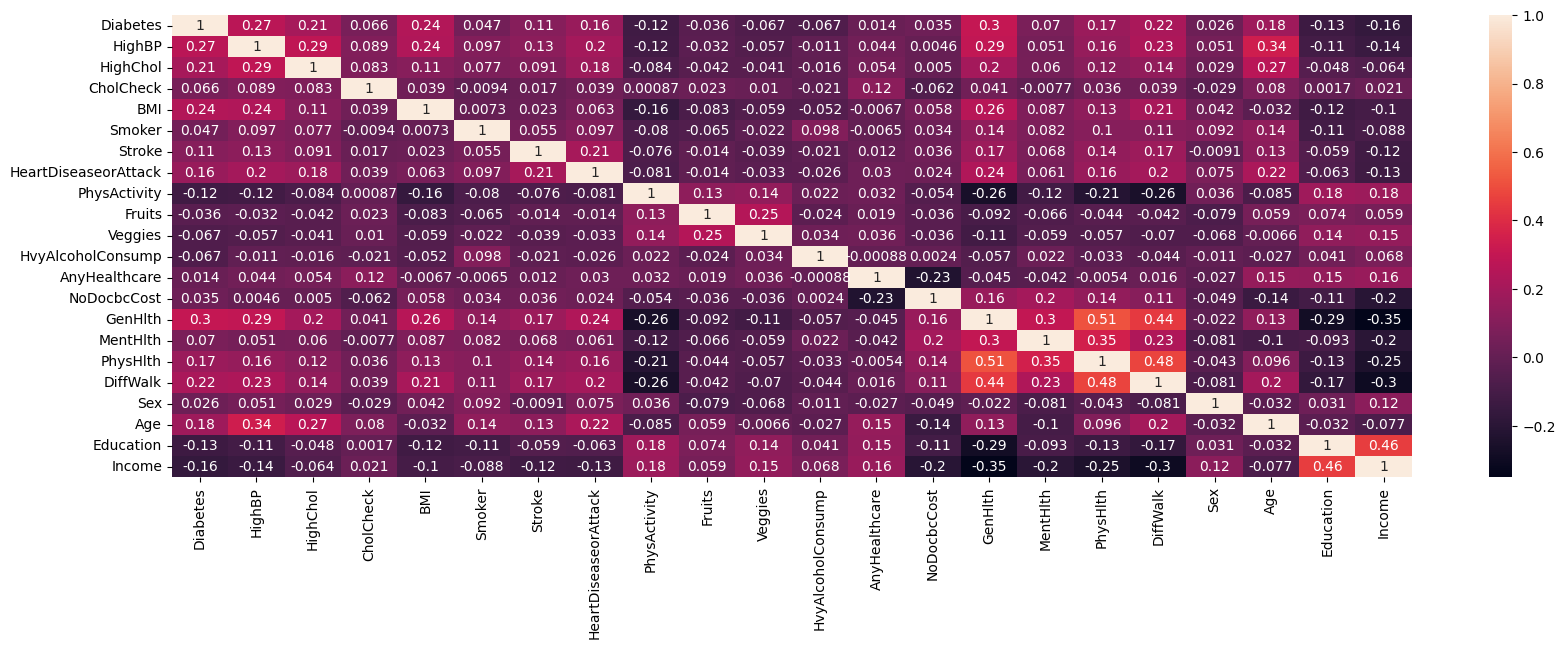

In [16]:
plt.figure(figsize=(20,6))
sns.heatmap(df.corr(), annot=True)

Feature & Target Separation

In [17]:
x=df.drop('Diabetes',axis=1)
y=df['Diabetes']

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
numerical_columns = x.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = x.select_dtypes(include='object').columns

In [20]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [21]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [22]:
preprocessing = ColumnTransformer([
    ('num', num_pipeline, numerical_columns),
    ('cat', cat_pipeline, categorical_columns)
])

In [23]:
pip install xgboost

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [25]:
algorithms = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "NaiveBayes": GaussianNB()
}

In [47]:
from sklearn.metrics import f1_score

results=[]
for name, model in algorithms.items():
    models = Pipeline([
        ('preprocessing', preprocessing),
        ('model', model)
    ])
    models.fit(x_train, y_train)
    y_pred = models.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1_score_value = f1_score(y_test, y_pred, average='weighted') # Use weighted for multi-class or customize as needed
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-score: {f1_score_value:.4f}")
    print(classification_report(y_test, y_pred))
    results.append((name, accuracy, f1_score_value,avg_model_acc))


Cross Validation Scores: [0.84067396 0.83697901 0.85513673 0.84759793 0.84951959]
Mean CV Accuracy: 0.8459814441102516
--- LogisticRegression ---
Accuracy: 0.8450
F1-score: 0.8038
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.91      5667
         1.0       0.00      0.00      0.00       147
         2.0       0.57      0.18      0.27       952

    accuracy                           0.84      6766
   macro avg       0.47      0.39      0.39      6766
weighted avg       0.80      0.84      0.80      6766



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Cross Validation Scores: [0.73987585 0.73839787 0.7751663  0.76585366 0.75757576]
Mean CV Accuracy: 0.7553738869557561
--- DecisionTree ---
Accuracy: 0.7588
F1-score: 0.7639
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86      5667
         1.0       0.04      0.05      0.04       147
         2.0       0.29      0.31      0.30       952

    accuracy                           0.76      6766
   macro avg       0.40      0.40      0.40      6766
weighted avg       0.77      0.76      0.76      6766



KeyboardInterrupt: 

In [38]:
model_acc=pd.DataFrame(results,columns=['Model','Accuracy','F1-Score','Avg_Model_Acc'])
model_acc.sort_values(by=['F1-Score','Avg_Model_Acc'],ascending=False)

,Model,Accuracy,F1-Score,Avg_Model_Acc
3,GradientBoosting,0.847177,0.806521,0.847371
4,XGBoost,0.842004,0.805152,0.841104
0,LogisticRegression,0.844960,0.803784,0.845981
2,RandomForest,0.841709,0.799303,0.842138
5,NaiveBayes,0.752439,0.769171,0.752124
1,DecisionTree,0.757316,0.762764,0.757029


In [49]:
from sklearn.model_selection import GridSearchCV

results = []

# Define parameter grids for each type of model
param_grids = {
    "LogisticRegression": {
        'model__C': [0.1, 1.0, 10.0],
        'model__solver': ['liblinear', 'lbfgs']
    },
    "DecisionTree": {
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10]
    },
    "RandomForest": {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5]
    },
    "GradientBoosting": {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1, 0.2],
        'model__max_depth': [3, 5]
    },
    "XGBoost": {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1, 0.2],
        'model__max_depth': [3, 5]
    },
    "NaiveBayes": {
        'model__var_smoothing': [1e-9, 1e-8, 1e-7]
    }
}

for name, model in algorithms.items():
    print(f"\n--- Tuning {name} ---")

    # Create the pipeline for the current model
    models_pipeline = Pipeline([
        ('preprocessing', preprocessing),
        ('model', model)
    ])

    # Get the appropriate parameter grid for the current model
    current_param_grid = param_grids.get(name)

    if current_param_grid is None:
        print(f"No parameter grid defined for {name}. Skipping tuning.")
        continue

    grid_search = GridSearchCV(
        estimator=models_pipeline, # Pass the pipeline as the estimator
        param_grid=current_param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=2
    )

    grid_search.fit(x_train, y_train)
    print("Best Parameters:", grid_search.best_params_)
    print("Best CV Score:", grid_search.best_score_)

    # You might want to store the best model or its performance in results list
    # For example:
    # results.append((name, grid_search.best_score_, grid_search.best_params_))



--- Tuning LogisticRegression ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'model__C': 0.1, 'model__solver': 'liblinear'}
Best CV Score: 0.8469752064129648

--- Tuning DecisionTree ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 10}
Best CV Score: 0.8333764121276568

--- Tuning RandomForest ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV Score: 0.8491924330425139

--- Tuning GradientBoosting ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV Score: 0.8502640777881503

--- Tuning XGBoost ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'model__learning_rate': 0.2, 'model__max_depth': 3, '